In [16]:
from sklearn.datasets import make_regression
import pandas as pd 
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### by using the make_regression we can generate the the data set of linear regression of any dimension

In [17]:
X,y = make_regression(n_samples=100, n_features=2, n_informative =2, n_targets=1, noise=50)

In [18]:
df = pd.DataFrame({'feature1':X[:,0], 'feature2':X[:,1], 'target':y})

In [19]:
df.shape

(100, 3)

In [20]:
df.head()

,feature1,feature2,target
0,1.924361,0.134128,62.355061
1,0.863099,0.417290,8.215123
2,1.885667,-0.693228,-3.302076
3,-0.140056,-0.357468,-74.066493
4,-0.176324,0.456747,62.363164


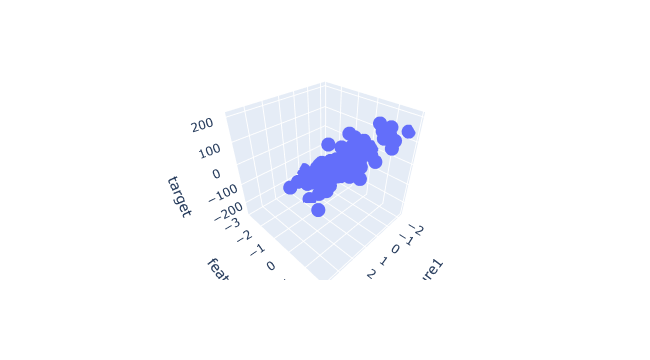

In [21]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr = LinearRegression()

In [25]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 2.89,90.88]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.118
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[9.57,8.38]"


In [26]:
y_pred = lr.predict(X_test)

In [27]:
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2", r2_score(y_test,y_pred))

MAE 41.053480346426184
MSE 2896.993511501216
R2 0.6434583833502905


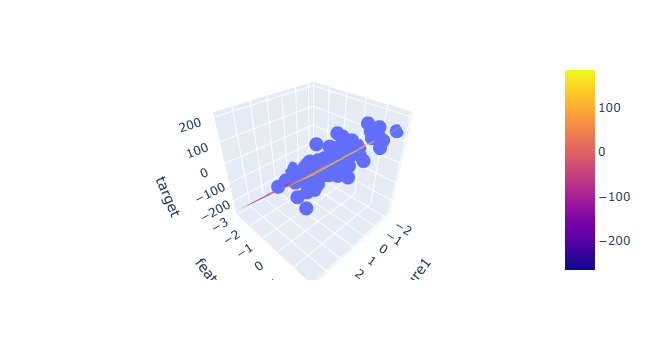

In [40]:
x = np.linspace(df['feature1'].min(), df['feature1'].max(), 20)
y = np.linspace(df['feature2'].min(), df['feature2'].max(), 20)

xGrid, yGrid = np.meshgrid(x, y)

final = np.c_[xGrid.ravel(), yGrid.ravel()]

z = lr.predict(final).reshape(xGrid.shape)

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='target'
)

fig.add_trace(
    go.Surface(
        x=xGrid,
        y=yGrid,
        z=z,
        opacity=0.6
    )
)

fig.show()

In [31]:
lr.coef_

array([ 2.89181745, 90.88315807])

In [32]:
lr.intercept_

np.float64(2.1178849103078488)

In [34]:
print(final.shape)

(100, 2)


In [35]:
print(z.shape)

(10, 10)
